# sc2ts on a simulated coronavirus: pilot

A first look at how well sc2ts recovers recombinants and the overall ARG when the
truth is known, using the SLiM pipeline in `simulations/slim`.

**Simulation.** A neutral, haploid Wright-Fisher population grows from a single founder
to 1,000 cases per generation over 20 generations, then stays at that size for 80
more (100 generations in all, ~83k individuals). The genome is 30 kb, with a mutation
rate of $1.2 \times 10^{-5}$ per site per generation: 0.0008 substitutions per site per
year with a 5.5 day generation time, as in the synthetic recombinant analysis, or about
0.36 mutations per genome per generation. 1% of births have two parents, with a single
uniformly placed breakpoint. Each generation is one sampling date for sc2ts.

**Sampling and inference.** Individuals are sampled from every generation with
probability $P = 0.02$ (1,643 samples) or $P = 0.1$ (8,226), with the samples at 0.02
a subset of those at 0.1. sc2ts is run with $k = 3, 4, 5$ and otherwise the parameters
used for the Viridian ARG, except that its time-traveller filtering is turned off: the
simulated samples have exact dates and no errors, so every sample is added on its own
day (see the "No time-traveller filtering" section of `simulations/slim/README.md`).
The final ARG is then run through `sc2ts postprocess`, which adds samples identical to
a node already in the ARG ("exact matches") as nodes of their own. One replicate.

**What counts as a recombinant.** A sample should be inferred to be a recombinant if it
is one itself, *or* if it inherits a recombination from an unsampled ancestor: walking
up its clonal line, it reaches a recombinant before reaching any individual placed in
the inferred ARG. Several samples can share one such recombinant ancestor; once sc2ts
has inferred that recombination in one of them, the rest correctly copy from it with
a single parent. So:

- **precision** is per sample: of the samples sc2ts matched with two parents, the
  fraction expected to be recombinants;
- **recall** is per recombination *event*: the fraction of recombinant ancestors for
  which at least one expected sample was matched with two parents.

Every sample ends up in the ARG, so all are scored.

Produced with:
```
cd simulations/slim
snakemake --cores 4 results/coronavirus/summary.csv --config 'p_values=[0.02,0.1]'
```
and `results/coronavirus/{summary,events,placement}.csv` copied to
`simulations/slim/pilot/` as `coronavirus_*.csv`.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

In [2]:
results_dir = Path("../simulations/slim/pilot")
# One row per run.
summary = pd.read_csv(results_dir / "coronavirus_summary.csv")
# One row per expected recombination event per run.
events = pd.read_csv(results_dir / "coronavirus_events.csv")
# Samples and placed samples per generation per run.
placement = pd.read_csv(results_dir / "coronavirus_placement.csv")

p_values = sorted(summary.p.unique())
k_values = sorted(summary.k.unique())
summary.shape, events.shape, placement.shape

((6, 26), (1194, 13), (561, 8))

In [3]:
# k and P are both ordered, so each is one hue stepped light to dark.
k_colors = dict(zip(k_values, ["#86b6ef", "#2a78d6", "#104281"]))
p_colors = dict(zip(p_values, ["#86b6ef", "#104281"]))
grid_kwargs = dict(color="0.9", linewidth=0.6)

# The median breakpoint interval in the Viridian ARG, from the paper.
PAPER_MEDIAN_INTERVAL = 2018


def clean_axes(ax):
    ax.yaxis.grid(True, **grid_kwargs)
    ax.set_axisbelow(True)
    for side in ["top", "right"]:
        ax.spines[side].set_visible(False)

## Summary

`exact_matches` is the number of samples added by `sc2ts postprocess`, `held_back` the
number sc2ts never added. `sampled` is the number of samples that are recombinants
themselves, `expected` the number that should be inferred to be recombinants, and
`events` the number of distinct recombinant ancestors behind them.

In [4]:
table = summary.set_index(["p", "k"])[
    [
        "num_samples",
        "num_placed",
        "num_exact_matches",
        "num_held_back",
        "num_sampled_recombinants",
        "num_expected_recombinants",
        "num_events",
        "num_inferred_recombinants",
        "false_positives",
        "precision",
        "events_detected",
        "recall",
        "recall_detectable",
        "breakpoint_in_interval",
    ]
].rename(
    columns=lambda c: c.replace("num_", "").replace("_recombinants", "")
)
table.round(3)

samples  placed  exact_matches  held_back  sampled  expected  events  \
p    k                                                                         
0.02 3     1643    1643            125          0       12       310     120   
     4     1643    1643            125          0       12       310     120   
     5     1643    1643            125          0       12       310     120   
0.10 3     8226    8226           2193          0       78       639     278   
     4     8226    8226           2193          0       78       639     278   
     5     8226    8226           2193          0       78       639     278   

        inferred  false_positives  precision  events_detected  recall  \
p    k                                                                  
0.02 3        94                7      0.926               83   0.692   
     4        82                3      0.963               76   0.633   
     5        67                0      1.000               64   0.533   
0.10 3       231                8      0.965              206   0.741   
     4       194                1      0.995              179   0.644   
     5       182                0      1.000              168   0.604   

        recall_detectable  breakpoint_in_interval  
p    k                                             
0.02 3              0.716                   0.901  
     4              0.655                   0.932  
     5              0.552                   0.937  
0.10 3              0.774                   1.000  
     4              0.673                   1.000  
     5              0.632                   1.000

## Precision and recall

Raising $k$ trades recall for precision, as on the real data. Precision is high
throughout (0.93 to 1): almost every sample sc2ts reports as a recombinant really does
carry an unrepresented recombination. Recall falls from about 0.7 at $k = 3$ to 0.5-0.6
at $k = 5$, and is similar at both sampling densities.

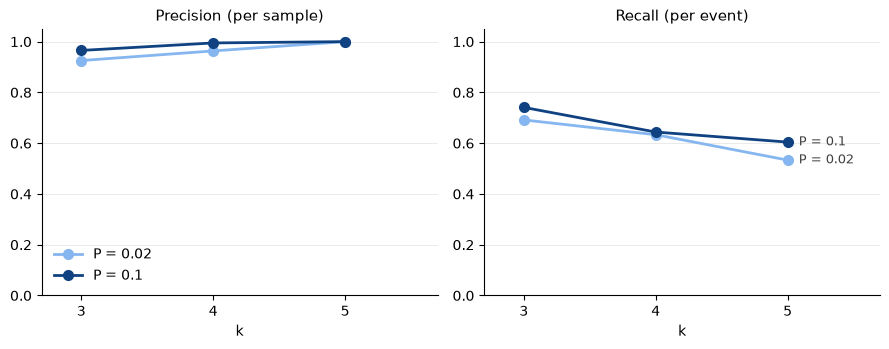

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.6), sharex=True)
for ax, column, title in zip(
    axes, ["precision", "recall"], ["Precision (per sample)", "Recall (per event)"]
):
    for p in p_values:
        df = summary[summary.p == p].sort_values("k")
        ax.plot(
            df.k, df[column], marker="o", markersize=7, linewidth=2,
            color=p_colors[p], label=f"P = {p}",
        )
        # Precision lines sit too close together to label directly.
        if column == "recall":
            ax.annotate(
                f"P = {p}", xy=(df.k.iloc[-1], df[column].iloc[-1]),
                xytext=(8, 0), textcoords="offset points", va="center", fontsize=9,
                color="0.25",
            )
    ax.set_title(title, fontsize=11)
    ax.set_xticks(k_values)
    ax.set_xlabel("k")
    ax.set_ylim(0, 1.05)
    ax.set_xlim(k_values[0] - 0.3, k_values[-1] + 0.7)
    clean_axes(ax)
axes[0].legend(frameon=False, loc="lower left")
fig.tight_layout()

## Which events are found

Detectable events (where the recombinant differs from both its parents; the rest leave
no trace), split by whether the recombinant itself was sampled and placed, or is only
seen through its descendants. Most events are only seen through descendants, and sc2ts
finds those at least as well as recombinants that were themselves sampled.

In [6]:
events["kind"] = np.where(events.sampled, "recombinant sampled", "descendants only")
(
    events[events.detectable]
    .groupby(["p", "k", "kind"])
    .detected.agg(["size", "mean"])
    .rename(columns={"size": "events", "mean": "recall"})
    .unstack("kind")
    .round(3)
)

events                               recall  \
kind   descendants only recombinant sampled descendants only   
p    k                                                         
0.02 3              104                  12            0.721   
     4              104                  12            0.663   
     5              104                  12            0.577   
0.10 3              191                  75            0.791   
     4              191                  75            0.696   
     5              191                  75            0.665   

                            
kind   recombinant sampled  
p    k                      
0.02 3               0.667  
     4               0.583  
     5               0.333  
0.10 3               0.733  
     4               0.613  
     5               0.547

## Exact matches

Every sample is in the ARG. A sample identical to a node already in the ARG is not
given a node of its own during inference, only counted against the node it matches;
`sc2ts postprocess` adds these exact matches as nodes under that node. With about 0.36
mutations per genome per generation, many samples are identical to a sampled relative:
8% of samples at $P = 0.02$ and 27% at $P = 0.1$, steady once the population has reached
its full size.

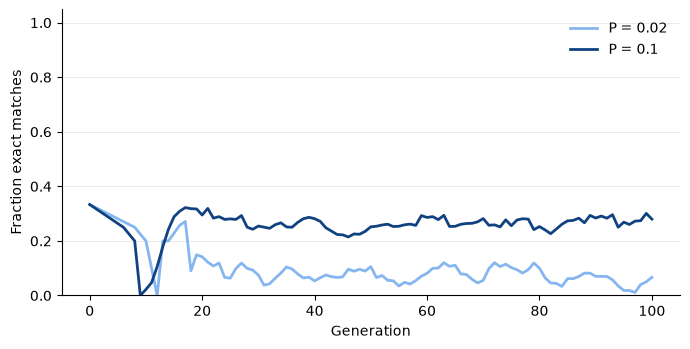

In [7]:
fig, ax = plt.subplots(figsize=(7, 3.6))
for p in p_values:
    df = placement[(placement.p == p) & (placement.k == 4)].set_index("gen")
    rate = df.num_exact_matches / df.num_samples
    # Smooth over 5 generations: few samples per generation at P = 0.02.
    smooth = rate.rolling(5, center=True, min_periods=1).mean()
    ax.plot(smooth.index, smooth.values, linewidth=2, color=p_colors[p], label=f"P = {p}")
ax.set_xlabel("Generation")
ax.set_ylabel("Fraction exact matches")
ax.set_ylim(0, 1.05)
ax.legend(frameon=False)
clean_axes(ax)
fig.tight_layout()

In [8]:
df = placement[placement.k == 4].groupby("p")[["num_samples", "num_exact_matches"]].sum()
(df.num_exact_matches / df.num_samples).round(3)

p
0.02    0.076
0.10    0.267
dtype: float64

## Breakpoints

Breakpoint intervals run from the last site supporting the left parent to the first
supporting the right. For events found with a single breakpoint (taking the earliest
sample the event was found in), the true breakpoint falls in the interval every time
at $P = 0.1$ and 90-94% of the time at $P = 0.02$. Interval widths are of the same
order as in the real ARG (dashed line; medians of about 1,400-1,550 bases at
$P = 0.1$ and 1,750 at $P = 0.02$, against 2,018), as expected with a similar
per-genome mutation rate.

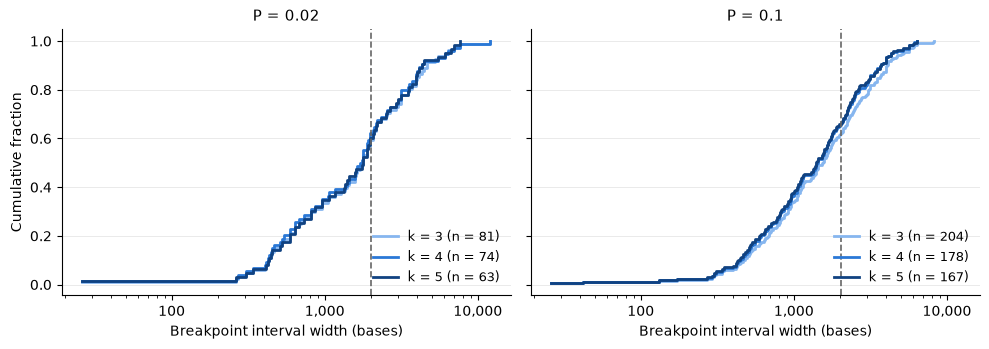

In [9]:
# Events found with a single breakpoint have an interval.
found = events.dropna(subset=["interval_width"])

fig, axes = plt.subplots(1, len(p_values), figsize=(10, 3.6), sharex=True, sharey=True)
for ax, p in zip(axes, p_values):
    for k in k_values:
        width = np.sort(found[(found.p == p) & (found.k == k)].interval_width.values)
        ax.step(
            width, np.arange(1, len(width) + 1) / len(width), where="post",
            linewidth=2, color=k_colors[k], label=f"k = {k} (n = {len(width)})",
        )
    ax.axvline(PAPER_MEDIAN_INTERVAL, color="0.4", linestyle="--", linewidth=1.2)
    ax.set_title(f"P = {p}", fontsize=11)
    ax.set_xscale("log")
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
    ax.xaxis.set_minor_formatter(mticker.NullFormatter())
    ax.set_xlabel("Breakpoint interval width (bases)")
    ax.legend(frameon=False, loc="lower right", fontsize=9)
    clean_axes(ax)
axes[0].set_ylabel("Cumulative fraction")
fig.tight_layout()

In [10]:
found.groupby(["p", "k"]).interval_width.median()

p     k
0.02  3    1768.0
      4    1728.0
      5    1768.0
0.10  3    1539.0
      4    1424.5
      5    1404.0
Name: interval_width, dtype: float64

## ARG accuracy

`tscompare.haplotype_arf(inferred, true)`, over all samples. `arf` is the
fraction of the inferred ARG's node span not found in the true ARG, `tpr` the fraction
of the true ARG's span found in the inferred one, and `rmse` the error in log node
times (in generations) of matched nodes.

Accuracy is lower at $P = 0.1$ than at $P = 0.02$, which is down to the exact matches:
identical sequences carry no information about how they are related, and sc2ts places
them all directly under the node they match, while the true genealogy among them is
resolved. Leaving the exact matches out of the comparison (checked for $P = 0.1$,
$k = 4$, outside this notebook) gives an ARF of 0.177 and TPR of 0.620, the same as at
$P = 0.02$.

In [11]:
summary.set_index(["p", "k"])[["arf", "tpr", "rmse"]].round(3)

arf    tpr   rmse
p    k                     
0.02 3  0.176  0.623  0.102
     4  0.175  0.626  0.099
     5  0.179  0.625  0.099
0.10 3  0.221  0.589  0.056
     4  0.222  0.588  0.056
     5  0.223  0.588  0.056

## Notes

- Turning off sc2ts's time-traveller filtering made the biggest difference at low
  sampling density. With the Viridian settings (`hmm_cost_threshold` 7), 39% of samples
  at $P = 0.02$ were held back and never added, and recall there was only 0.41, 0.31
  and 0.17 for $k = 3, 4, 5$. With every sample added, recall at $P = 0.02$ is close to
  that at $P = 0.1$.
- Precision is high at every $k$; the few false positives (at most 8 in a run) are
  worth looking at individually.
- ARF and TPR barely change with $k$. Recombination is rare enough that the clonal
  topology dominates the node-span comparison, so these measure tree accuracy more
  than recombinant accuracy, and at high sampling density they are dominated by how
  exact matches are placed.
- One replicate, one parameter set: no uncertainty estimates yet.